# Decision Tree Regressor - Working

A **Decision Tree Regressor** predicts **continuous numerical values** by recursively splitting the dataset into smaller subsets. The objective is to create groups where the target values are as similar as possible.

## Steps

1. **Start with the entire dataset.**
2. **Try every feature and every possible threshold** to split the data.
3. **Compute the Variance Reduction (or MSE Reduction)** for each split.
4. **Choose the split with the highest variance reduction.**
5. **Recursively repeat** the process for the left and right child nodes.
6. Stop splitting when a stopping criterion is met:

   * Maximum depth reached
   * Minimum samples reached
   * Node variance becomes zero
7. **Store the mean of the target values** in each leaf node.
8. During prediction, traverse the tree according to the feature values and return the mean stored in the reached leaf.

## Key Differences from Decision Tree Classifier

| Decision Tree Classifier   | Decision Tree Regressor           |
| -------------------------- | --------------------------------- |
| Predicts classes           | Predicts continuous values        |
| Uses Gini / Entropy        | Uses Variance / MSE               |
| Maximizes Information Gain | Maximizes Variance Reduction      |
| Leaf stores majority class | Leaf stores mean of target values |

## Workflow

```text
Start with all training data
        │
        ▼
Try every feature & threshold
        │
        ▼
Compute Variance Reduction
        │
        ▼
Choose the best split
        │
        ▼
Split the dataset
        │
        ▼
Repeat recursively
        │
        ▼
Stopping criteria met
        │
        ▼
Store mean(target) in each leaf
        │
        ▼
Prediction = Mean stored in the reached leaf
```


In [1]:
import torch
torch.manual_seed(42)

In [ ]:
# Classes needed:
# Variance
# SplitDataset
# Node
# DecisionTreeRegressor

## Variance

### Weighted Variance

After splitting a node, we calculate the variance of the left and right child nodes. Since the two child nodes may contain different numbers of samples, we compute a **weighted average** of their variances.

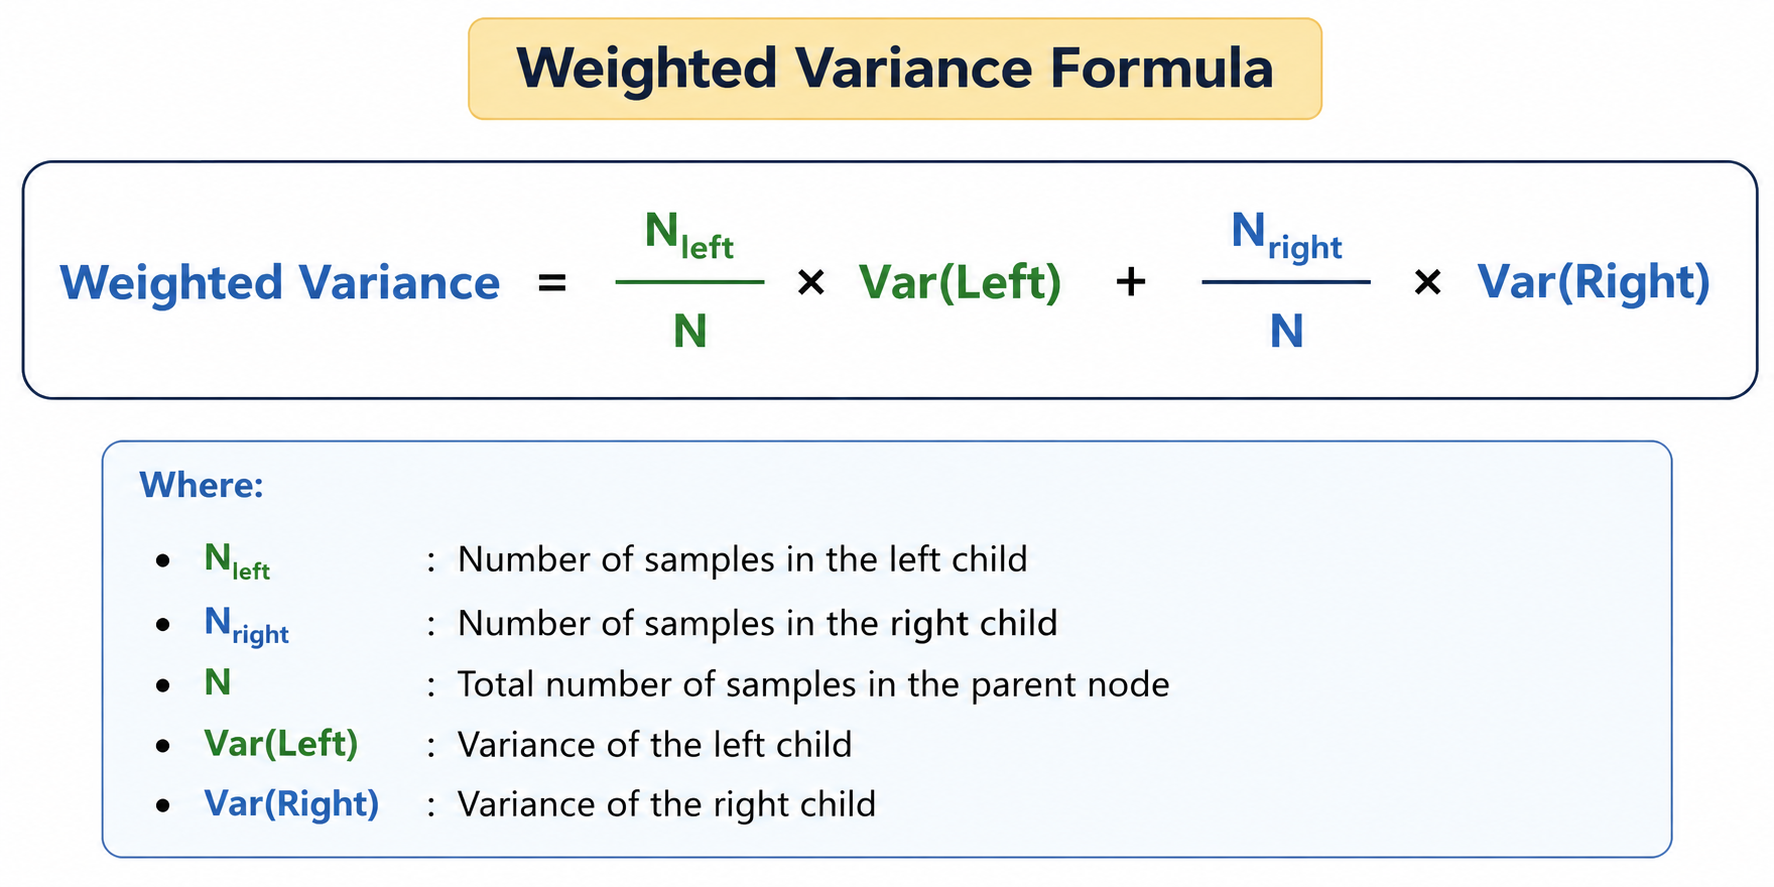

A good split produces a **low weighted variance**, meaning the target values in both child nodes are more homogeneous.

In [10]:
# class Variance:
#     def __call__(self,y):
#         mean = y.mean()
#         return torch.sum(torch.y([(i-mean)**2 for i in y])/y.shape[0])

class Variance:
    def __call__(self, y):
        mean = y.mean()
        return ((y - mean) ** 2).mean()


class Variance_Reduction:
    def __init__(self):
        self.variance = Variance()
    def __call__(self,y,y_left,y_right):
        weighted_variance = (y_left.shape[0]/y.shape[0])*self.variance(y_left) + (y_right.shape[0]/y.shape[0])*self.variance(y_right)
        return   self.variance(y) - weighted_variance

## Split Dataset

In [3]:
class SplitDataset:
    def __call__(self, X, y, feature_idx, threshold):
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask

        X_left = X[left_mask]
        y_left = y[left_mask]

        X_right = X[right_mask]
        y_right = y[right_mask]

        return X_left, y_left, X_right, y_right

## Best Split

In [8]:
class BestSplit:
    def __init__(self):
        self.split_dataset = SplitDataset()
        self.variance_reduction = Variance_Reduction()

    def __call__(self, X, y):

        best_score = -float("inf")
        best_feature = None
        best_threshold = None
        best_split = None

        n_features = X.shape[1]

        for feature_idx in range(n_features):

            thresholds = torch.unique(X[:, feature_idx])

            for threshold in thresholds:

                X_left, y_left, X_right, y_right = self.split_dataset(
                    X,
                    y,
                    feature_idx,
                    threshold
                )

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gain = self.variance_reduction(y, y_left, y_right)

                if gain > best_score:
                    best_score = gain
                    best_feature = feature_idx
                    best_threshold = threshold
                    best_split = (X_left, y_left, X_right, y_right)

        return best_feature, best_threshold, best_score, best_split

# Node

In [4]:
class Node:
    def __init__(self,feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    @property
    def is_leaf(self):
        return self.value is not None

# Decision Tree

In [5]:
class DecisionTree:

    def __init__(self, max_depth=10, min_samples_split=2):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.best_split = BestSplit()
        self.root = None

    def _build_tree(self, X, y, depth=0):

        # Stop if all labels are same
        if len(torch.unique(y)) == 1:
            return Node(value=y[0].item())

        # Maximum depth
        if depth >= self.max_depth:
            value = y.mean().item()
            return Node(value=value)

        # Minimum samples
        if len(y) < self.min_samples_split:
            value = y.mean().item()
            return Node(value=value)

        feature_idx, threshold, best_score, split = self.best_split(X, y)

        if split is None or best_score <= 0:
            value = y.mean().item()
            return Node(value=value)

        X_left, y_left, X_right, y_right = split
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return Node(feature_idx=feature_idx, threshold=threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        self.root = self._build_tree(X, y)

    def _predict_one(self, x, node):

        if node.is_leaf:
            return node.value

        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)

        return self._predict_one(x, node.right)

    def predict(self, X):

        predictions = [
            self._predict_one(x, self.root)
            for x in X
        ]

        return torch.tensor(predictions)

# Dataset

In [12]:
# 200 samples, 1 feature
X = torch.linspace(-3, 3, 200).reshape(-1, 1)

# Non-linear target with a little noise
y = X.squeeze()**2 + 2 * torch.sin(3 * X.squeeze())
y += 0.3 * torch.randn_like(y)

# Shuffle indices
indices = torch.randperm(len(X))

# 80-20 split
train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

In [13]:
model = DecisionTree(max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [14]:
mse = ((y_test - y_pred) ** 2).mean()
print(f"MSE: {mse:.4f}")

MSE: 0.2663


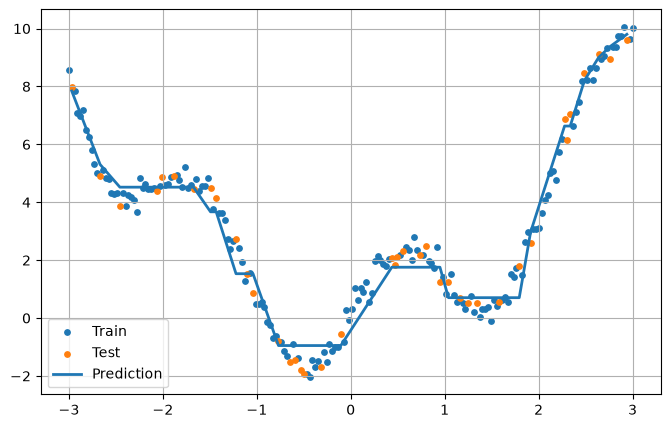

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(X_train.numpy(), y_train.numpy(), s=15, label="Train")
plt.scatter(X_test.numpy(), y_test.numpy(), s=15, label="Test")

# Sort for a smooth prediction curve
sorted_idx = torch.argsort(X_test.squeeze())

plt.plot(
    X_test[sorted_idx].numpy(),
    y_pred[sorted_idx].numpy(),
    linewidth=2,
    label="Prediction"
)

plt.legend()
plt.grid(True)
plt.show()